In [38]:
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 

In [39]:
from torchvision.datasets import CIFAR10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)  
CIFAR10_STD = (0.2023, 0.1994, 0.2010)


# Apply in your data loader with torchvision.transforms
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

train_dataset = CIFAR10(
    root="./datasets",
    train=True,
    download=True,
    transform=transform
)

test_dataset = CIFAR10(
    root="./datasets",
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

print(torch.__version__)
print(torch.version.cuda)

cuda
2.12.0+cu130
13.0


In [ ]:
import torch
import torch.nn as nn

class CNN_(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=6, kernel_size=3)
        self.maxpool = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(in_channels=6, out_channels=8, kernel_size=3)
        self.conv4 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3)
        self.conv5 = nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3)
        self.conv6 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3)
        self.dropoutConv6 = nn.Dropout(p=0.3)

        self.fc1 = nn.Linear(16, 32)
        self.dropoutFC1 = nn.Dropout(p = 0.4)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):

        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.maxpool(x)
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        x = self.maxpool(x)
        x = torch.relu(self.conv5(x))
        x = torch.relu(self.conv6(x))
        x = self.dropoutConv6(x)


        x = torch.flatten(x, start_dim=1)
        x = self.dropoutFC1(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)   

        return x


model = CNN_()

In [42]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

def accuracy(loader): 
    model.eval()
    
    correct = 0 ; total = 0 

    with torch.no_grad():
        for img, label in loader: 

            img = img.to(device)
            label = label.to(device)

            yhat = model(img)
            yhat = torch.argmax(yhat, dim=1)
            correct += (label == yhat).sum().item()

            total += len(yhat)

        return 100 * (correct/total)



In [43]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle=True)


In [44]:
import time 

epochs = 50 
loss_rec = []
accuracy_rec_test = []
accuracy_rec_train = []

model = model.to(device)

for i in range(epochs): 

    model.train()

    s = time.time()
    device = 'cuda'
    current_loss = 0 
    for img, label in train_loader:
        img = img.to(device)
        label = label.to(device)
        yhat = model(img)
        optimizer.zero_grad()
        loss = loss_fn(yhat, label)
        loss.backward()
        optimizer.step()

        current_loss += loss.item()
    current_loss = current_loss/len(train_loader)

    accuracy_test = accuracy(test_loader)
    accuracy_train = accuracy(train_loader)

    accuracy_rec_train.append(accuracy_train)
    accuracy_rec_test.append(accuracy_test)
    loss_rec.append(current_loss) 
    end = time.time() - s
    print(f"Epoch : {i+1}  || Loss : {loss:.2f} || Accuracy ( Train dataset ) : {accuracy_train:.2f} || Accuracy ( Test dataset ): {accuracy_test:.2f} || Time taken : {end:.2f}")



Epoch : 1  || Loss : 1.72 || Accuracy ( Train dataset ) : 34.48 || Accuracy ( Test dataset ): 34.75 || Time taken : 15.11
Epoch : 2  || Loss : 1.28 || Accuracy ( Train dataset ) : 39.86 || Accuracy ( Test dataset ): 39.86 || Time taken : 14.23
Epoch : 3  || Loss : 1.66 || Accuracy ( Train dataset ) : 42.14 || Accuracy ( Test dataset ): 42.20 || Time taken : 14.77
Epoch : 4  || Loss : 1.64 || Accuracy ( Train dataset ) : 45.87 || Accuracy ( Test dataset ): 45.82 || Time taken : 14.58
Epoch : 5  || Loss : 1.55 || Accuracy ( Train dataset ) : 46.27 || Accuracy ( Test dataset ): 46.11 || Time taken : 14.80
Epoch : 6  || Loss : 1.56 || Accuracy ( Train dataset ) : 48.89 || Accuracy ( Test dataset ): 47.77 || Time taken : 15.46
Epoch : 7  || Loss : 1.20 || Accuracy ( Train dataset ) : 49.69 || Accuracy ( Test dataset ): 49.48 || Time taken : 15.12
Epoch : 8  || Loss : 1.45 || Accuracy ( Train dataset ) : 50.58 || Accuracy ( Test dataset ): 49.75 || Time taken : 15.16
Epoch : 9  || Loss : 1.2

In [45]:
accuracy = accuracy(test_loader)
print(accuracy)

59.11


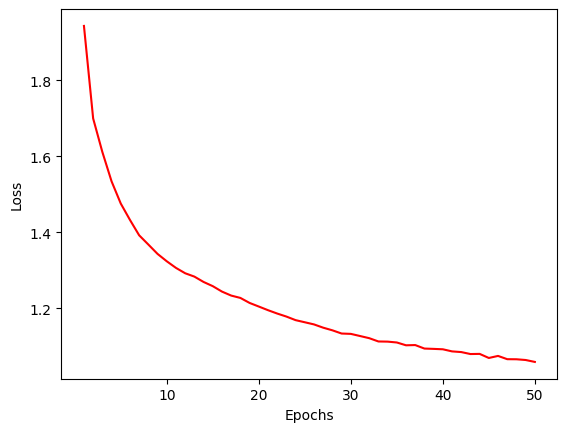

In [46]:
import numpy as np 
ep = np.arange(50) + 1

plt.plot(ep, loss_rec, color='red')
plt.xticks(ep[ep%10 == 0])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

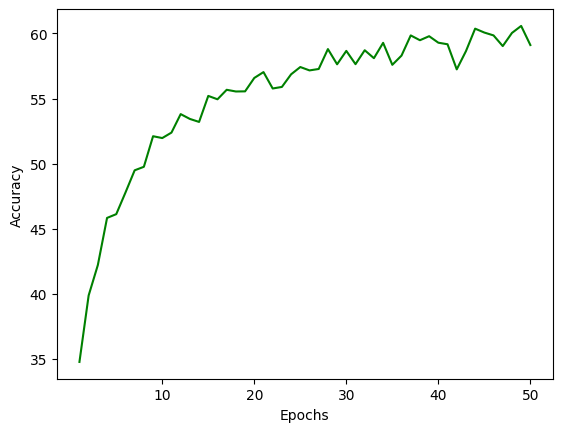

In [47]:
plt.plot(ep, accuracy_rec_test, color='green')
plt.xticks(ep[ep%10 == 0])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [48]:
import sklearn 
from sklearn.metrics import confusion_matrix

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_hat = []
y_true = []

with torch.no_grad(): 
    for images, labels in test_loader: 

        images = images.to("cuda")
        labels = labels.to("cuda")

        y_hat_batch = torch.argmax(model(images), dim=1)
        y_true_batch = labels 

        y_hat.extend(y_hat_batch.cpu().numpy())
        y_true.extend(y_true_batch.cpu().numpy())




cnf_mat = confusion_matrix(y_pred=y_hat , y_true=y_true)

In [49]:
cnf_mat

array([[586,  47,  68,  53,  43,  19,   9,  23,  91,  61],
       [ 21, 719,   5,  26,  10,  10,  17,  13,  32, 147],
       [ 72,  10, 335, 143, 150, 154,  52,  61,  11,  12],
       [ 13,   9,  36, 502,  62, 250,  42,  53,   6,  27],
       [ 28,   8,  51, 125, 497,  72,  59, 151,   5,   4],
       [  9,   4,  35, 277,  46, 537,  15,  68,   2,   7],
       [  3,   8,  24, 180,  84,  37, 650,   8,   1,   5],
       [  6,   1,  18,  86,  62, 129,   4, 672,   2,  20],
       [114,  67,  10,  50,  15,   8,   5,  11, 641,  79],
       [ 17,  64,   4,  38,  10,  15,   5,  49,  26, 772]])

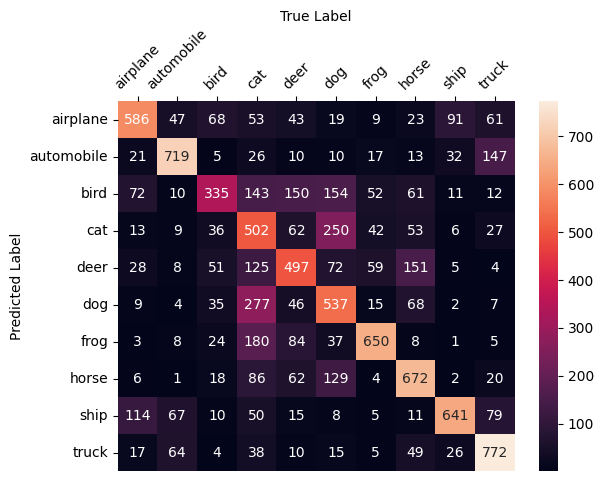

In [50]:
import seaborn as sns 

ax = sns.heatmap(cnf_mat,xticklabels=classes, yticklabels=classes, annot=True, fmt='d')
plt.ylabel("Predicted Label")
plt.xlabel("True Label")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [51]:
print("Loss : ", loss_rec )
print("accuracy_rec_test", accuracy_rec_test )
print("accuracy_rec_train", accuracy_rec_train) 

Loss :  [1.9437604415447205, 1.6998907611193255, 1.6116020062085612, 1.534323692474219, 1.4757873896137832, 1.432642532431561, 1.3920701278749938, 1.3676891839107894, 1.343018277298154, 1.3236336861272602, 1.3061835250586196, 1.2920786031829121, 1.2832510847874614, 1.2691274783038118, 1.2580676920273726, 1.2437384099606663, 1.2332604798819402, 1.22706578157442, 1.213877312133989, 1.2043740436091752, 1.1947843716729938, 1.1859196342928024, 1.1779477568843482, 1.1685349801769647, 1.1629281402243983, 1.1572760027235427, 1.1486603219795715, 1.141713965198268, 1.1332581793255818, 1.132342106088653, 1.1267156922603812, 1.1210164971211378, 1.1123479952287796, 1.1119282024595745, 1.109661290941336, 1.1022577179819726, 1.1028667837000259, 1.0936494848459883, 1.0928036141426056, 1.091746328736815, 1.0862061143531214, 1.0844068677376604, 1.0792152192586524, 1.0796103536168022, 1.068844326621736, 1.0742599628770444, 1.0656551049493463, 1.0654303059553552, 1.0635000612882093, 1.0584498707900571]
ac

In [ ]:
# # just relu 
# Loss :  [1.7630162969269716, 1.4106459799782394, 1.2758248418645786, 1.167960738129628, 1.06969210452131, 0.9897516478815347, 0.9197347417969228, 0.8528001485273357, 0.7864529503428418, 0.7179696521033412, 0.6480985768234638, 0.5816262252724079, 0.5079043373808532, 0.4489042817441094, 0.38373450502334044, 0.34021960421825004, 0.28164710584656355, 0.25091171041702676, 0.2125013108077028, 0.19695333892579578, 0.17668300554813707, 0.1527269470703114, 0.1478262115067438, 0.13504242270951494, 0.11384072440230976, 0.11640082723210993, 0.12277371076571629, 0.10291825356069104, 0.11503141756822138, 0.10200155415343563, 0.08691600917736092, 0.09854868434124228, 0.0872190318688455, 0.08171818651052912, 0.09472266458930052, 0.08503509360922934, 0.08337012704347482, 0.09086490274124714, 0.0641659684848431, 0.0900022044180609, 0.07296742489823448, 0.07115212400995262, 0.0757642543509655, 0.07646685168581784, 0.06894935449332837, 0.07642316213562428, 0.06285541049381027, 0.07400642614647904, 0.06535760116177763, 0.057112597946442016]
# accuracy_rec_test [45.53, 52.01, 54.25, 57.550000000000004, 58.74, 58.76, 60.99, 60.160000000000004, 59.91, 58.550000000000004, 57.15, 58.3, 57.03, 57.06, 56.47, 55.800000000000004, 55.95, 55.75, 54.279999999999994, 54.169999999999995, 54.690000000000005, 54.56999999999999, 54.37, 53.94, 54.99000000000001, 53.49, 53.800000000000004, 54.02, 53.89000000000001, 52.93, 54.39000000000001, 53.800000000000004, 53.5, 53.580000000000005, 53.61, 53.790000000000006, 53.71, 53.38, 53.769999999999996, 53.480000000000004, 53.38, 53.49, 53.15, 53.239999999999995, 53.66, 53.53, 54.35, 53.03, 52.92, 53.2]
# accuracy_rec_train [46.53, 53.628, 57.858, 62.35000000000001, 65.06, 67.632, 72.636, 73.416, 76.244, 77.986, 79.324, 84.572, 85.19, 89.71000000000001, 91.488, 91.666, 93.768, 94.086, 94.71199999999999, 93.672, 95.336, 95.422, 94.158, 96.788, 97.832, 95.17999999999999, 95.192, 97.478, 97.81800000000001, 96.258, 97.52, 96.048, 98.292, 97.512, 96.88799999999999, 97.70400000000001, 97.828, 97.72999999999999, 97.328, 97.142, 97.75399999999999, 98.194, 98.14399999999999, 97.89, 98.30799999999999, 97.76599999999999, 98.734, 97.19200000000001, 97.328, 98.738]

### Added max pooling ( better generalization )

#Loss :  [1.9437604415447205, 1.6998907611193255, 1.6116020062085612, 1.534323692474219, 1.4757873896137832, 1.432642532431561, 1.3920701278749938, 1.3676891839107894, 1.343018277298154, 1.3236336861272602, 1.3061835250586196, 1.2920786031829121, 1.2832510847874614, 1.2691274783038118, 1.2580676920273726, 1.2437384099606663, 1.2332604798819402, 1.22706578157442, 1.213877312133989, 1.2043740436091752, 1.1947843716729938, 1.1859196342928024, 1.1779477568843482, 1.1685349801769647, 1.1629281402243983, 1.1572760027235427, 1.1486603219795715, 1.141713965198268, 1.1332581793255818, 1.132342106088653, 1.1267156922603812, 1.1210164971211378, 1.1123479952287796, 1.1119282024595745, 1.109661290941336, 1.1022577179819726, 1.1028667837000259, 1.0936494848459883, 1.0928036141426056, 1.091746328736815, 1.0862061143531214, 1.0844068677376604, 1.0792152192586524, 1.0796103536168022, 1.068844326621736, 1.0742599628770444, 1.0656551049493463, 1.0654303059553552, 1.0635000612882093, 1.0584498707900571]
# accuracy_rec_test [34.75, 39.86, 42.199999999999996, 45.82, 46.11, 47.77, 49.480000000000004, 49.75, 52.1, 51.959999999999994, 52.38, 53.800000000000004, 53.43, 53.2, 55.2, 54.94, 55.669999999999995, 55.54, 55.55, 56.58, 57.03, 55.769999999999996, 55.88999999999999, 56.86, 57.42, 57.16, 57.269999999999996, 58.8, 57.63, 58.660000000000004, 57.64, 58.709999999999994, 58.099999999999994, 59.28, 57.589999999999996, 58.3, 59.85, 59.48, 59.79, 59.29, 59.17, 57.24, 58.64, 60.370000000000005, 60.07, 59.85, 59.03, 60.040000000000006, 60.58, 59.11]
# accuracy_rec_train [34.476, 39.864, 42.138, 45.873999999999995, 46.272000000000006, 48.892, 49.686, 50.583999999999996, 52.769999999999996, 52.686, 53.442, 54.54, 54.018, 53.738, 56.006, 55.891999999999996, 56.762, 56.858, 56.69800000000001, 57.654, 58.072, 57.635999999999996, 57.428000000000004, 58.821999999999996, 58.814, 58.794000000000004, 58.556, 60.01800000000001, 59.128, 60.040000000000006, 59.419999999999995, 60.394000000000005, 59.78, 61.25000000000001, 59.038000000000004, 59.86, 61.696, 61.318, 61.297999999999995, 61.228, 61.0, 59.51, 60.738, 61.739999999999995, 61.870000000000005, 61.99400000000001, 60.907999999999994, 62.486, 62.58200000000001, 61.366]